In [1]:
import pandas as pd 
import numpy as np
import os 
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.ticker import MaxNLocator

In [58]:
df = pd.read_csv("ai_chorales.csv")

In [16]:
df.shape

(5880, 17)

# Data prep

In [59]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%dT%H-%M-%S-%fZ", utc=True)

In [60]:
df.head()

,participant_id,timestamp,age,musical_experience,plays_instrument,sings_in_choir,uses_ai_weekly,confidence_before,confidence_after,difficulty,free_feedback,stimulus,response,correct,correct_response,rt,training
0,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/153.5-3.wav,x,m,False,9871,False
1,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/256-5.wav,m,m,True,7578,False
2,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/227.11-5.wav,m,m,True,9041,False
3,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/122.6-4.wav,x,m,False,9712,False
4,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/A/output48-2.wav,x,x,True,8551,False


In [61]:
df = df[[
    'participant_id', 
    'timestamp',
    'age',
    'musical_experience',
    'plays_instrument',
    'sings_in_choir',
    'uses_ai_weekly',
    'confidence_before',
    'confidence_after',
    'difficulty',
    # free_feedback,
    'stimulus',
    'response',  
    'correct',
    'correct_response',
    'rt', 
    # 'training',
        ]]

In [62]:
# transform to 1 column per participant for categorical analyses
unique_participants = df.drop_duplicates(subset=["participant_id"])
print(f"Number of participants: {len(unique_participants)}")



Number of participants: 294


# Data eval

Mean:   30.1 years old
Median: 25.0 years old


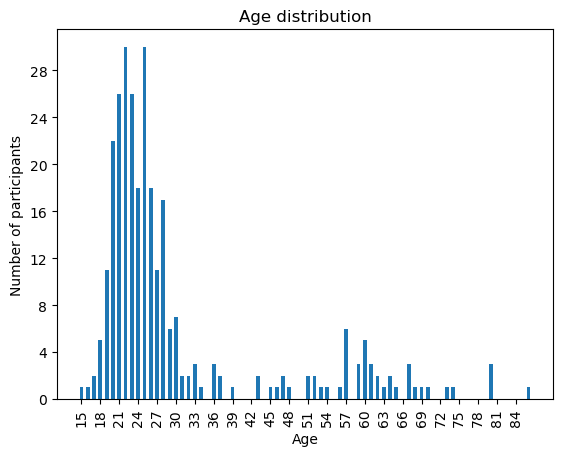

In [51]:

# Age distribution

unique_ages = unique_participants["age"]

age_min, age_max = int(unique_ages.min()), int(unique_ages.max())
unique_ages.plot(
    kind="hist", 
    bins=range(age_min, age_max + 2), 
    align='left',
    rwidth=0.6, # Adds a slight gap between bars for readability
    ylabel="Number of participants", 
    xlabel="Age",
    title="Age distribution"
)



plt.xticks(range(age_min, age_max + 1, 3), rotation=90)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# print metrics
print("Mean:  ", round(unique_ages.mean(), 1), "years old")
print("Median:", round(unique_ages.median(), 1), "years old")

plt.show()

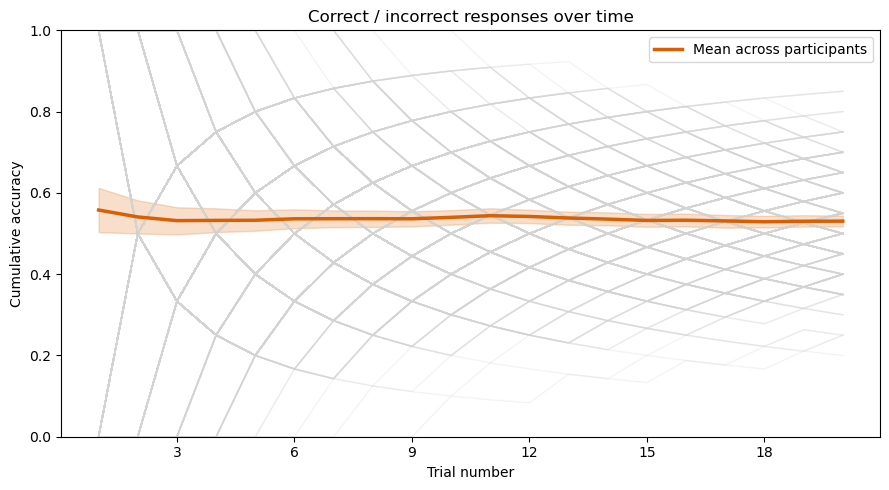

In [ ]:
# experiment performance over time 

# every participant gets color in the graph;
# model correct / incorrect response over the trial number (=experiment duration)
# show accuracy over time 

# Data Prep
df = df.copy()
df["trial_number"] = df.groupby("participant_id").cumcount() +1
df["cumulative_acc"] = (
    df.groupby("participant_id")["correct_response"]
    .expanding() # include all rows up to the current one
    .mean()
    .reset_index(level=0, drop=True) # remove index created by "groupby", only keep value column
)

# plot

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=df,
    x="trial_number",
    y="cumulative_acc",
    units="participant_id",
    estimator=None,
    color="lightgray",
    alpha=0.25,
    linewidth=1,
    legend=False
)

sns.lineplot(
    data=df,
    x="trial_number",
    y="cumulative_acc",
    estimator="mean",
    color="#d95f02",
    linewidth=2.5,
    label="Mean across participants"
)
plt.title("Correct / incorrect responses over time")
plt.xlabel("Trial number")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel("Cumulative accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


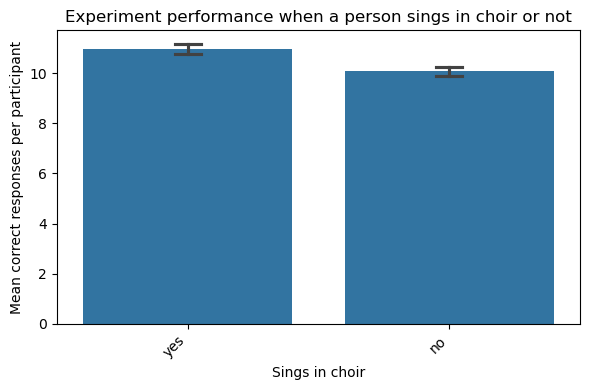

In [27]:
# Average correct repsonses by sings_in_choir

translation_dict = {"ja": "yes", "nein": "no"}

df["sings_in_choir"] = df["sings_in_choir"].map(translation_dict)

participant_summary = (
    df.groupby(["participant_id", "sings_in_choir"], as_index=False)["correct_response"]
    .sum()
)

order = ["yes", "no"]

plt.figure(figsize=(6, 4))
sns.barplot(
    data=participant_summary,
    x="sings_in_choir",
    order=order,
    y="correct_response",
    errorbar="se",
    capsize=0.1
)
plt.ylabel("Mean correct responses per participant")
plt.xlabel("Sings in choir")
plt.title("Experiment performance when a person sings in choir or not")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


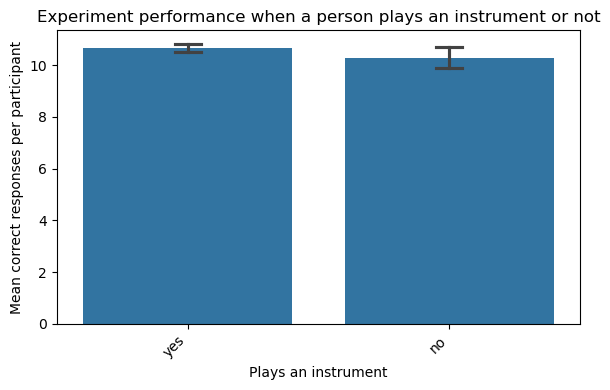

In [38]:
# Average correct responses by "plays_instrument"

translation_dict = {"ja": "yes", "nein": "no"}

df["plays_instrument"] = df["plays_instrument"].map(translation_dict)

participant_summary = (
    df.groupby(["participant_id", "plays_instrument"], as_index=False)["correct_response"]
    .sum()
)

order = ["yes", "no"]

plt.figure(figsize=(6, 4))
sns.barplot(
    data=participant_summary,
    x="plays_instrument",
    order=order,
    y="correct_response",
    errorbar="se",
    capsize=0.1
)
plt.ylabel("Mean correct responses per participant")
plt.xlabel("Plays an instrument")
plt.title("Experiment performance when a person plays an instrument or not")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

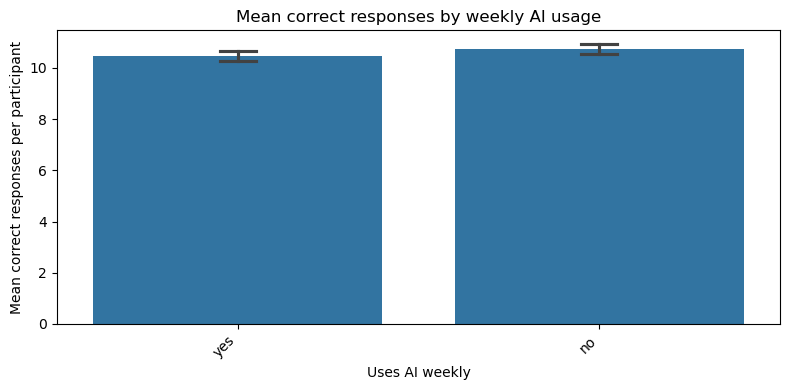

In [28]:
# Average correct responses by weekly ai usage

translation_dict = {"ja": "yes", "nein": "no"}

df["uses_ai_weekly"] = df["uses_ai_weekly"].map(translation_dict)
participant_summary = (
    df.groupby(["participant_id", "uses_ai_weekly"], as_index=False)["correct_response"]
    .sum()
)



order = ["yes", "no"]
plt.figure(figsize=(8, 4))
sns.barplot(
    data=participant_summary,
    x="uses_ai_weekly",
    order=order,
    y="correct_response",
    errorbar="se",  # Options: 'ci' (confidence interval) or 'se' (standard error)
    capsize=0.1,
    legend=False
)

plt.ylabel("Mean correct responses per participant")
plt.xlabel("Uses AI weekly")
plt.title("Mean correct responses by weekly AI usage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

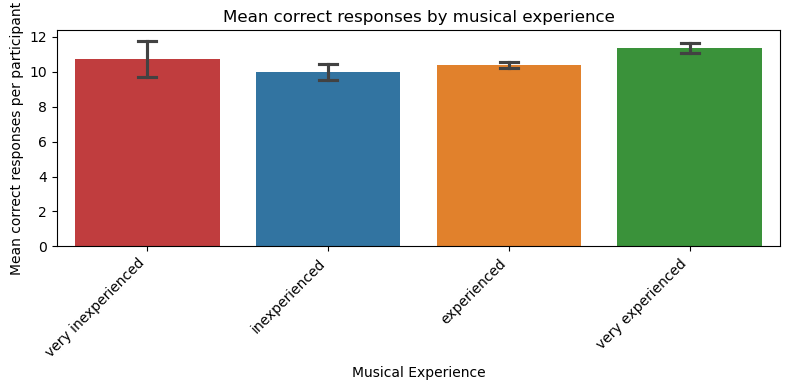

In [29]:
# impact of musical experience on experiment result
translation_dict = {"sehr unerfahren": "very inexperienced",
                    "unerfahren": "inexperienced",
                    "erfahren": "experienced",
                    "sehr erfahren": "very experienced"
                    }

df["musical_experience"] = df["musical_experience"].map(translation_dict)

participant_summary = (
    df.groupby(["participant_id", "musical_experience"], as_index=False)["correct_response"]
      .sum()
)


order = ["very inexperienced", "inexperienced", "experienced", "very experienced"]


plt.figure(figsize=(8, 4))
sns.barplot(
    data=participant_summary,
    x="musical_experience",
    y="correct_response",
    order=order,   
    errorbar="se",     
    capsize=0.1,       
    hue="musical_experience",
    legend=False
)
plt.ylabel("Mean correct responses per participant")
plt.xlabel("Musical Experience")
plt.title("Mean correct responses by musical experience")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# participant_summary["musical_experience"] = participant_summary["musical_experience"].astype("category")
# participant_summary["experience_code"] = participant_summary["musical_experience"].cat.codes

# print("Experience categories:", participant_summary["musical_experience"].cat.categories.tolist())
# print(participant_summary.groupby("musical_experience", observed=True)["correct_response"].agg(["count", "mean", "median"]))

# print("\nPearson correlation (category codes):",
#       participant_summary["experience_code"].corr(participant_summary["correct_response"]))
# print("\nSpearman correlation (category codes):",
#       participant_summary["experience_code"].corr(participant_summary["correct_response"], method="spearman"))

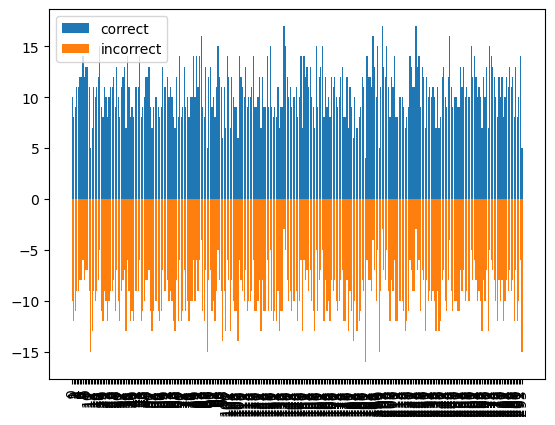

In [30]:
# Correct response distribution

responses_indiv = pd.Series([(g["correct_response"].sum(), 20 - g["correct_response"].sum()) for n, g in df.groupby("timestamp") ])
# responses_indiv.value_counts().sort_index().plot(kind="bar", xlabel="Correct responses", ylabel="Number of participants");

correct = np.array([r[0] for r in responses_indiv])
incorrect = -np.array([r[1] for r in responses_indiv])

xx = np.arange(len(correct), dtype=int)

_, ax = plt.subplots()
ax.bar(xx, correct, label="correct")#
# ax.axhline(correct.mean(), c="k")

ax.bar(xx, incorrect, label="incorrect")
# ax.axhline(incorrect.mean(), c="k")
plt.xticks(xx, rotation=90)
plt.legend()


Mean: 0.4822201607915894
Median:  0.4914965986394558


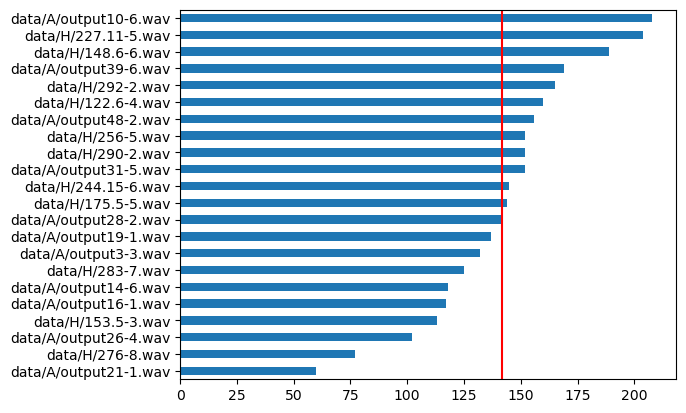

In [37]:
indices, values = zip(*[(n, g["correct_response"].sum()) for n, g in df.groupby("stimulus")])

responses_piece = pd.Series(values, index=indices).sort_index()

_, ax = plt.subplots()
responses_piece.sort_values().plot(kind="barh", ax=ax)
avg = responses_piece.mean()
ax.axvline(avg, c="red")
# ax.axvline(responses_piece.median(), c="green")
print("Mean:", avg / len(unique_participants))
print("Median: ", responses_piece.median() / len(unique_participants));

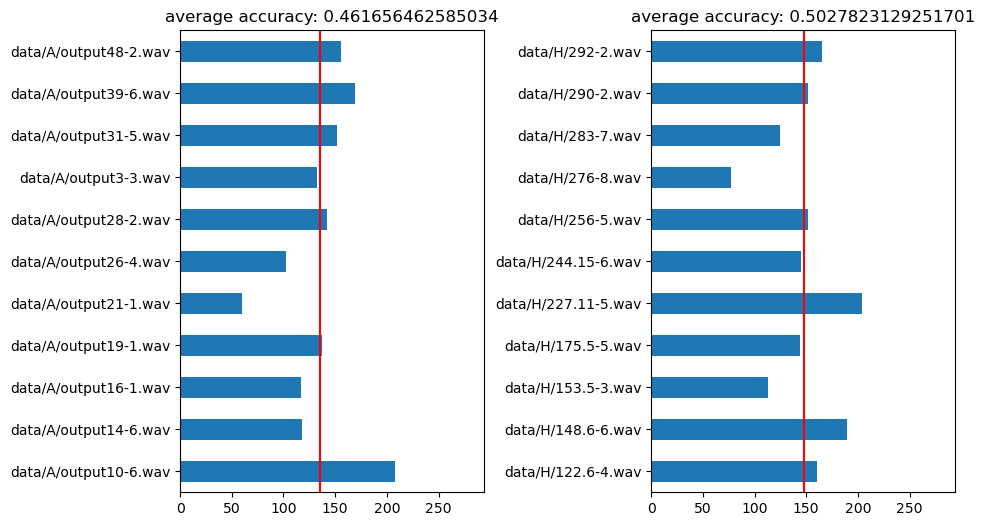

In [35]:
responses_A, responses_H = responses_piece[:11], responses_piece[11:]

_, axes = plt.subplots(1,2, figsize=(10,6), gridspec_kw={"wspace": .55})
for i, r in enumerate([responses_A, responses_H]):
    r.plot(kind="barh", ax=axes[i])
    avg = round(r.mean(), 3)
    axes[i].axvline(avg, c="red")
    axes[i].set_title(f"average accuracy: {avg/len(unique_participants)}")
    axes[i].set_xlim(0,len(unique_participants))


**Notizen**

- Alle Beispiele von Menschen einspielen lassen? Oder besser erklären, dass alles maschinell ab gespielt wird.
- Vergleichen: Einspielung vs Synthetisch?
- Bach-Choräle beliebt zum Trainieren, aber wenig Kontakt für Schüler. Wie funktioniert es bei "zugänglicheren" Sachen?
- Frage erweitern: Kann KI-Musik von menschlicher unterscheiden? Ausweitung der Genres etc.
- Notentext einbeziehen? --> Hypothese: Aufgabe wird leichter
- Mit SCB durchführen (oder Choräle spielen lassen)